In [2]:
import pandas as pd

df = pd.read_csv("exchange_dataset.csv", parse_dates=["date"], index_col="date")

df.head()

,usdkrw,dgs2,dgs10,dfii10,t10yie,vix,stlfsi,dxy
date,,,,,,,,
2021-03-05,1124.85,0.14,1.56,-0.66,2.22,24.66,-0.4014,113.7487
2021-03-12,1133.09,0.14,1.64,-0.62,2.26,20.69,-0.4933,113.0269
2021-03-19,1130.38,0.16,1.74,-0.57,2.31,20.95,-0.5398,112.9756
2021-03-26,1129.26,0.14,1.67,-0.67,2.34,18.86,-0.6213,113.7406
2021-04-09,1120.84,0.16,1.67,-0.64,2.31,16.69,-0.8131,113.2028


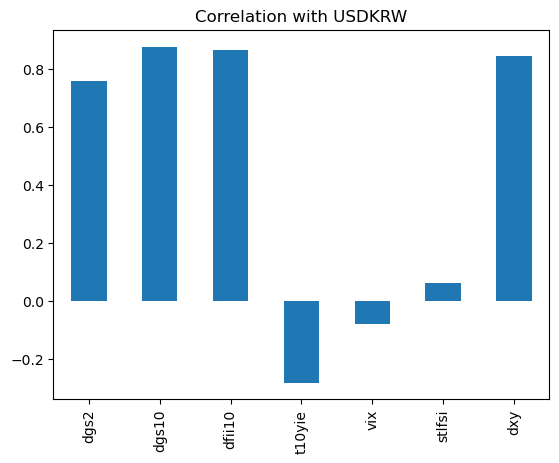

In [8]:
# 환율과의 상관관계
import matplotlib.pyplot as plt

df.corr()["usdkrw"].drop("usdkrw").plot(kind="bar")
plt.title("Correlation with USDKRW")
plt.show()
# df.corr()["usdkrw"].sort_values(ascending=False)

In [9]:
X = df.drop(columns=["usdkrw"])
y = df["usdkrw"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9183978165342889


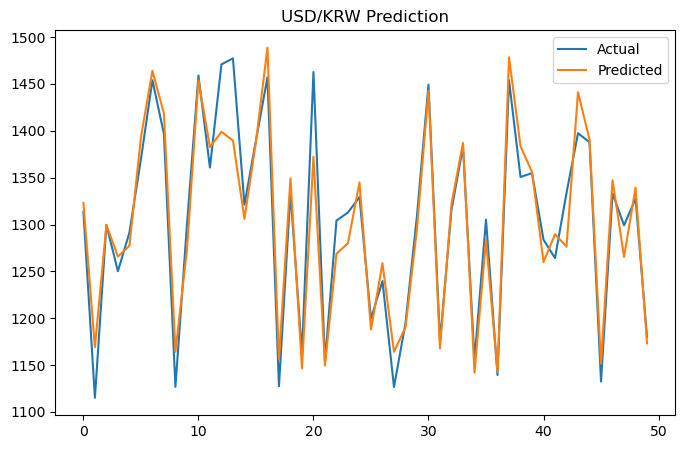

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("USD/KRW Prediction")
plt.show()